In [205]:
import numpy as np
import cv2 as cv
import glob
import matplotlib.pyplot as plt

In [206]:
# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [207]:
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((5*7,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:5].T.reshape(-1,2)

In [208]:
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

In [209]:
images = glob.glob('*.png')
images

['image_big.png', 'kalibrierung.png']

False
True


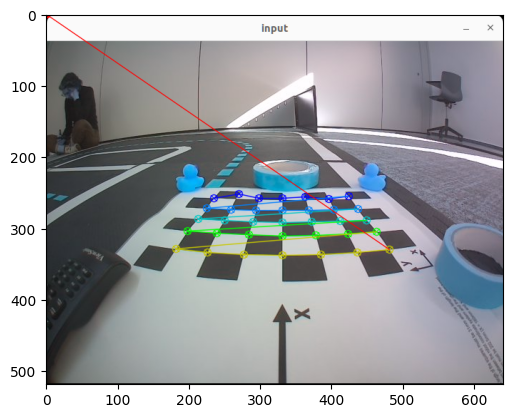

In [210]:
for fname in images:
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
 
    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (7,5), None)
    print(ret)
    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)
 
        corners2 = cv.cornerSubPix(gray,corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)
 
        # Draw and display the corners
        cv.drawChessboardCorners(img, (7,6), corners2, ret)
        plt.imshow(img)
        #cv.imshow('img', img)
        #cv.waitKey(500)

#cv.destroyAllWindows()
 

In [211]:
corners

array([[[235.06386, 257.62854]],

       [[269.62994, 251.53603]],

       [[298.25702, 258.4885 ]],

       [[331.3195 , 257.7377 ]],

       [[362.54614, 256.34805]],

       [[395.89178, 258.88245]],

       [[423.7955 , 255.03339]],

       [[225.42987, 272.4317 ]],

       [[258.84055, 273.60464]],

       [[294.39975, 274.70557]],

       [[331.01877, 275.30923]],

       [[367.6    , 275.30566]],

       [[403.2366 , 274.47476]],

       [[436.74008, 273.48337]],

       [[213.49107, 287.22415]],

       [[250.2068 , 289.46674]],

       [[289.70294, 290.65375]],

       [[330.76932, 291.56238]],

       [[372.11685, 291.45502]],

       [[411.696  , 290.4066 ]],

       [[448.50433, 288.572  ]],

       [[198.4832 , 304.01373]],

       [[239.06174, 307.1843 ]],

       [[283.80316, 309.48282]],

       [[330.72845, 310.69437]],

       [[377.82767, 310.4178 ]],

       [[422.65015, 308.34296]],

       [[463.48917, 305.4771 ]],

       [[181.57512, 329.41675]],

       [[226.2

In [212]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

In [213]:
img = cv.imread('image_big.png')
h,  w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

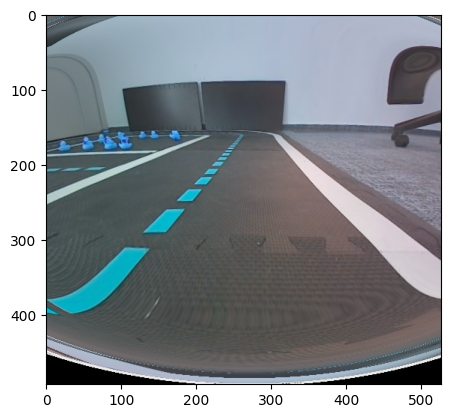

In [214]:
# undistort
dst = cv.undistort(img, mtx, dist, None, newcameramtx)
 
# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]
#cv.imwrite('calibresult.png', dst)
plt.imshow(dst)

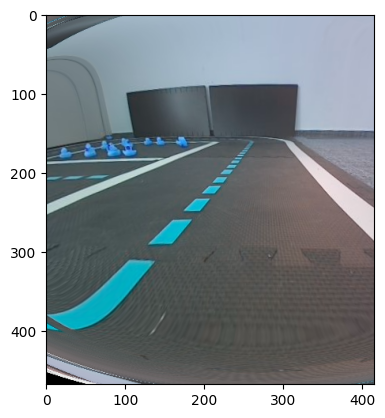

In [215]:
# undistort
mapx, mapy = cv.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w,h), 5)
dst = cv.remap(img, mapx, mapy, cv.INTER_LINEAR)
 
# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]
plt.imshow(dst)


In [216]:
# Function to map image coordinates to world coordinates
def image_to_world(img_point, mtx, dist, rvec, tvec):
    # undistort the image point
    img_point = np.array([[img_point]], dtype='float32')
    undistorted_point = cv.undistortPoints(img_point, mtx, dist)
    
    # Convert from 2D to 3D using the homography (essentially projecting onto the floor)
    # Here, we assume the floor lies at z = 0 in world coordinates, so we solve for x and y.
    
    # Example assuming a simple 2D homography solution based on a known floor plane:
    # We use the camera matrix and rotation/translation vectors to find the world coordinates
    
    # Convert image points to normalized coordinates (in the camera frame)
    normalized_point = np.linalg.inv(mtx).dot(np.array([undistorted_point[0][0][0], undistorted_point[0][0][1], 1]))
    print(normalized_point)
    
    # Get rotation and translation matrix from rvecs and tvecs
    rotation_matrix, _ = cv.Rodrigues(rvec)
    transformation_matrix = np.hstack((rotation_matrix, tvec))

    # Define the floor plane (z = 0) in world coordinates
    # We need to solve for x, y using a homography or similar projection method
    # Here we'll assume a simple transformation for a flat floor
    
    homogeneous_point = np.array([normalized_point[0], normalized_point[1], 1, 1])
    print(homogeneous_point)
    world_point = np.dot(transformation_matrix, homogeneous_point)
    print(world_point)
    return world_point[:2]  # Return x, y on the floor


In [219]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
image_to_world((300,300),mtx,dist,rvecs[0],tvecs[0])

[-1.6191382  -2.26219962  1.        ]
[-1.6191382  -2.26219962  1.          1.        ]
[-4.53604902  1.4218917   8.43479919]


array([-4.53604902,  1.4218917 ])

In [ ]:
image_point = [300,300]

rotation_matrix, _ = cv.Rodrigues(rvecs[0])
transformation_matrix = np.hstack((rotation_matrix, tvecs[0]))


# Normalize the image point by inverting the intrinsic matrix
# Convert to homogeneous coordinates (with z=1)
image_point_homogeneous = np.array([image_point[0], image_point[1], 1.0])

# Invert the camera matrix to get the normalized coordinates in camera space
normalized_image_point = np.linalg.inv(mtx).dot(image_point_homogeneous)

# Now, we need to reverse the projection and solve for the world coordinates at z = 0
# The ray in camera space is (normalized_image_point.x, normalized_image_point.y, 1),
# and it should intersect the plane z = 0 (the floor).
# The formula is: scale_factor = -tvec[2] / (rotation_matrix[2, 0] * normalized_image_point[0] +
#                                         rotation_matrix[2, 1] * normalized_image_point[1] +
#                                         rotation_matrix[2, 2])

# Calculate the scaling factor for the ray to intersect the z = 0 plane
scale_factor = -tvecs[0][2] / (rotation_matrix[2, 0] * normalized_image_point[0] +
                           rotation_matrix[2, 1] * normalized_image_point[1] +
                           rotation_matrix[2, 2])

# Now calculate the world coordinates (x, y, 0) where z = 0
world_point_camera_coordinates = scale_factor * np.array([normalized_image_point[0], normalized_image_point[1], 1])

# Apply the rotation and translation to get the coordinates in the world frame
world_point = rotation_matrix.dot(world_point_camera_coordinates) + tvecs[0]

# The world coordinates of the point on the floor (z = 0)
print(f"World Coordinates (Floor Plane, z=0): {world_point}")


World Coordinates (Floor Plane, z=0): [-113.61025422  585.41243213  802.68708955]


In [ ]:
import numpy as np
import cv2



# Camera extrinsic parameters: rotation (rvec) and translation (tvec)
# Example values, replace them with actual calibration results
rvec = rvecs[0].reshape((3))
tvec = tvecs[0].reshape((3))
# Convert rotation vector to rotation matrix using Rodrigues
rotation_matrix, _ = cv2.Rodrigues(rvec)

# Example image point (in pixels)
image_point = np.array([300, 300])  # Image point (x, y) in pixel coordinates

# Normalize the image point by inverting the intrinsic matrix
# Convert to homogeneous coordinates (with z=1)
image_point_homogeneous = np.array([image_point[0], image_point[1], 1.0])

# Invert the camera matrix to get the normalized coordinates in camera space
normalized_image_point = np.linalg.inv(mtx).dot(image_point_homogeneous)

# The ray in camera space is (normalized_image_point.x, normalized_image_point.y, 1),
# and it should intersect the plane z = 0 (the floor).
# We solve for the scale_factor that projects the ray onto the floor (z = 0 plane).
# Ray equation:  t * normalized_image_point = (x, y, z)  with z = 0

# The equation to find the scaling factor is:
# 0 = t * normalized_image_point[2] + tvec[2] + rotation_matrix[2, 0] * t * normalized_image_point[0] +
#     rotation_matrix[2, 1] * t * normalized_image_point[1]

# Calculate the scaling factor for the ray to intersect the z = 0 plane
denominator = rotation_matrix[2, 0] * normalized_image_point[0] + \
              rotation_matrix[2, 1] * normalized_image_point[1] + \
              rotation_matrix[2, 2] * 1  # (we use normalized_image_point[2] = 1)
scale_factor = -(tvec[2] + denominator) / denominator  # Solving for t

# Now calculate the world coordinates (x, y, 0) where z = 0
camera_coordinates = scale_factor * normalized_image_point[:2]

# Apply the rotation and translation to get the coordinates in the world frame
world_point_camera_coordinates = rotation_matrix.dot(np.array([camera_coordinates[0], camera_coordinates[1], 0])) + tvec

# The world coordinates of the point on the floor (z = 0)
print(f"World Coordinates (Floor Plane, z=0): {world_point_camera_coordinates}")


World Coordinates (Floor Plane, z=0): [-2.61033797  1.40570312  6.76774681]


In [ ]:
rvecs[0].reshape((3))

array([-0.94712192, -0.00197531,  0.01182275])